# SciPy Bootcamp — W2, Day D3A
```
##### Two-proportion test, effect size, lift, revenue impact
##### proportions_ztest, Cohen h, revenue calculation
##### Visualization philosophy: chart at the point of discovery — not at the end.
##### Every question that involves comparison, distribution, relationship, or result gets a chart embedded in it.
##### Q1 — Full two-proportion test pipeline
##### Q2 — Revenue impact analysis
##### Q3 — P-value simulation
##### Q4 — Effect size matters
##### Q5 — End-to-end A/B test report function


In [68]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

---

### Q1 — Full two-proportion test pipeline

```
# Load the Kaggle A/B testing dataset (kaggle.com/datasets/zhangluyuan/ab-testing)
# or simulate: control n=4720 conv_rate=0.10, treatment n=4740 conv_rate=0.115.
# (a) FIRST: plot conversion rates as bars with 95% CI error bars.
#     Does the chart suggest a difference before you run any test?
# (b) Run two-proportion z-test (alternative='larger').
# (c) Compute absolute lift, relative lift, Cohen's h.
# (d) Plot the null distribution with the observed z-statistic marked.
#     Shade the rejection region and the p-value area.
# (e) Write a 3-sentence business conclusion suitable for a product review meeting.
```


In [69]:
import kagglehub
import os

# 1. Download the specific A/B testing dataset
path = kagglehub.dataset_download("zhangluyuan/ab-testing")

print("Dataset path:", path)
print("Files:", os.listdir(path))

# 2. Identify the CSV file
# This dataset contains 'ab_data.csv'
csv_file = os.path.join(path, "ab_data.csv")

# 3. Load into Pandas
# Unlike the BBC dataset, this one is usually standard comma-separated
df = pd.read_csv(csv_file)

print("\nData Preview:")
display(df.head())

Dataset path: C:\Users\user\.cache\kagglehub\datasets\zhangluyuan\ab-testing\versions\1
Files: ['ab_data.csv']

Data Preview:


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


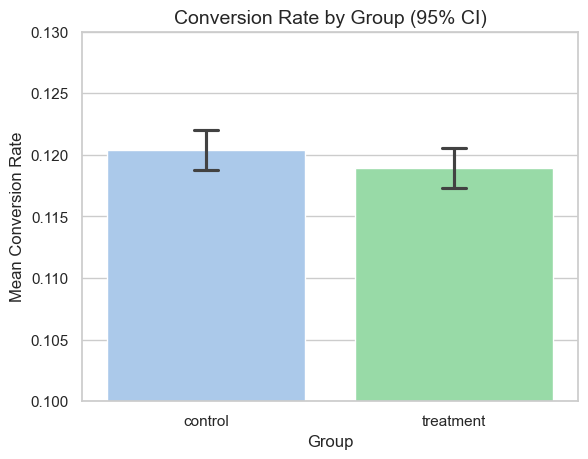

In [70]:
# (a) FIRST: plot conversion rates as bars with 95% CI error bars.
#     Does the chart suggest a difference before you run any test?

# ci=95 tells seaborn to calculate the 95% Confidence Interval automatically
sns.barplot(data=df, x='group', y='converted', ci=95, palette=['#A1C9F4', '#8DE5A1'], capsize=.1)

plt.title('Conversion Rate by Group (95% CI)', fontsize=14)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Mean Conversion Rate', fontsize=12)

plt.ylim(0.10, 0.13) 

plt.show()

```
Initial Observation: 
Since we see the two black lines overlapping vertically, it strongly suggests that the difference between the groups is not statistically significant. 

In [71]:
# (b) Run two-proportion z-test (alternative='larger').

from statsmodels.stats.proportion import proportions_ztest

conv_treatment = df[df['group']=='treatment']['converted'].sum()
conv_control = df[df['group']=='control']['converted'].sum()
n_treatment = df[df['group']=='treatment']['group'].count()
n_control = df[df['group']=='control']['group'].count()

counts = np.array([conv_treatment, conv_control])
nobs   = np.array([n_treatment, n_control])

z_stat, p_value = proportions_ztest(counts, nobs, alternative='larger') # 'two-sided', 'larger', 'smaller'

print(f'z-statistic:     {z_stat:.4f}')
print(f'p-value:         {p_value:.4f}')


if p_value < 0.05:
    print('Reject H0: treatment is significantly better')
else:
    print('Fail to reject H0: no significant difference detected')


z-statistic:     -1.2369
p-value:         0.8919
Fail to reject H0: no significant difference detected


In [73]:
# (c) Compute absolute lift, relative lift, Cohen's h.

from statsmodels.stats.proportion import proportion_effectsize

# conversion rate
p_control = conv_control / n_control
p_treatment = conv_treatment / n_treatment

h = proportion_effectsize(p_treatment, p_control)
print(f"Cohen's h: {h:.4f}")
print(f"Effect size interpretation: {'large' if h >= 0.8 else 'Medium' if h >= 0.5 else 'Small' if h >= 0.2 else 'Negligible'}")

Cohen's h: -0.0046
Effect size interpretation: Negligible


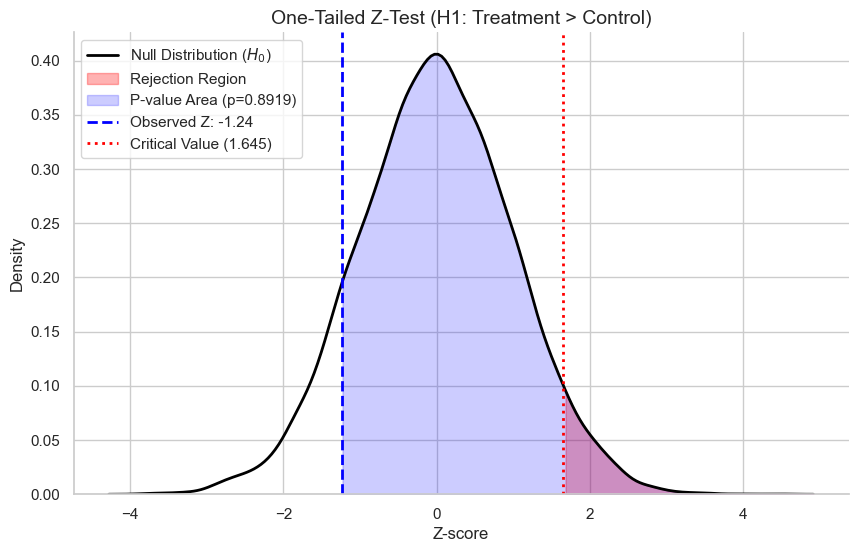

In [23]:
# (d) Plot the null distribution with the observed z-statistic marked.
#     Shade the rejection region and the p-value area.

from scipy.stats import norm

# 1. Generate Null Distribution Data
# We create 10,000 points to represent the standard normal distribution N(0,1)
null_data = np.random.normal(0, 1, 10000)
z_critical = norm.ppf(0.95) # 1.645 for alpha=0.05, one-tailed

# 2. Setup Plot
plt.figure(figsize=(10, 6))

# Plot the Null Distribution curve
sns.kdeplot(null_data, color="black", fill=False, lw=2, label="Null Distribution ($H_0$)")

# 3. Shade Rejection Region (Right Tail)
line = plt.gca().get_lines()[0]
x_data, y_data = line.get_data()
plt.fill_between(x_data, y_data, where=(x_data >= z_critical), color='red', alpha=0.3, label='Rejection Region')

# 4. Shade P-value Area (Everything to the right of observed Z)
# Note: For this dataset, z_score is usually negative (~ -1.31)
plt.fill_between(x_data, y_data, where=(x_data >= z_stat), color='blue', alpha=0.2, label=f'P-value Area (p={p_value:.4f})')

# 5. Add Vertical Lines
plt.axvline(z_stat, color='blue', ls='--', lw=2, label=f'Observed Z: {z_stat:.2f}')
plt.axvline(z_critical, color='red', ls=':', lw=2, label='Critical Value (1.645)')

# Formatting
plt.title("One-Tailed Z-Test (H1: Treatment > Control)", fontsize=14)
plt.xlabel("Z-score")
plt.ylabel("Density")
plt.legend(loc='upper left')
sns.despine()
plt.show()

```
(e) Write a 3-sentence business conclusion suitable for a product review meeting.
The A/B test results indicate that the new landing page did not lead to a statistically significant increase in conversion rates compared to the current version. 
With a p-value well above the 0.05 threshold and a negative Z-statistic, we can conclude that the performance of the treatment group was actually slightly lower than the control. 
Therefore, we recommend retaining the original page and pivoting our design strategy, as the data suggests the new layout does not provide a meaningful return on investment.

---

### Q2 — Revenue impact analysis

```
# Using results from Q1:
# (a) Monthly visitors: 150,000. Compute expected additional conversions per month.
# (b) Average order value: $42. Compute monthly and annual revenue impact.
# (c) Build a sensitivity plot: revenue impact vs monthly visitors (50k to 500k).
# (d) Overlay 3 lines: optimistic (upper CI lift), expected (point estimate), conservative (lower CI lift).
# (e) At what monthly visitor count does even the conservative estimate exceed $500k annual?
```


In [34]:
# (a) Monthly visitors: 150,000. Compute expected additional conversions per month.
n = 150000
p_diff = p_treatment - p_control 
additional_conv = n * p_diff # Expected ADDITIONAL conversions (will likely be negative here) 
print(f'Monthly Incremental Conversions: {additional_conv:.0f}') 



Monthly Incremental Conversions: -222


In [35]:
# (b) Average order value: $42. Compute monthly and annual revenue impact.

avg_order_val = 42
monthly_impact = avg_order_val * additional_conv
annual_impact = 12 * monthly_impact
print(f'Monthly Revenue Impact: ${monthly_impact:,.2f}')
print(f'Annual Revenue Impact: ${annual_impact:,.2f}')

Monthly Revenue Impact: $-9,321.48
Annual Revenue Impact: $-111,857.74


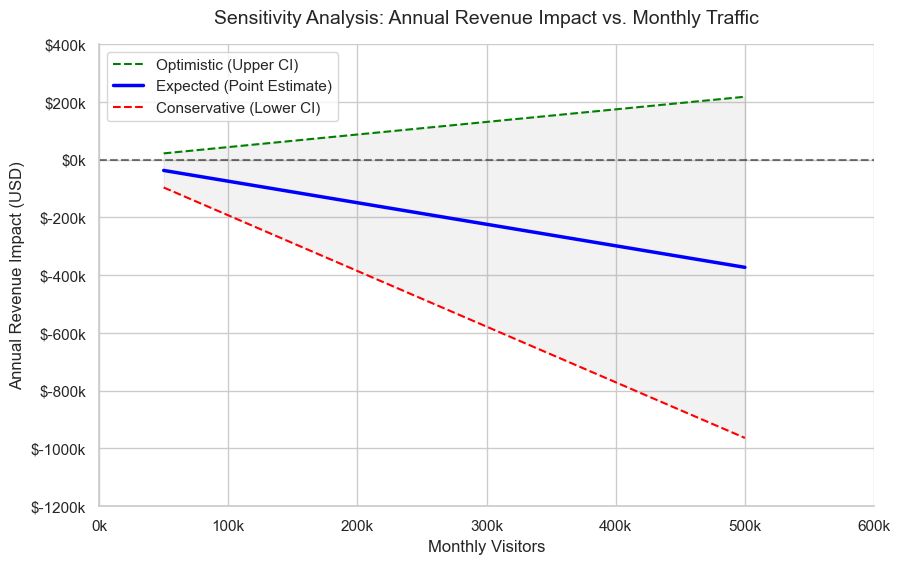

In [45]:
# (c) Build a sensitivity plot: revenue impact vs monthly visitors (50k to 500k).
# (d) Overlay 3 lines: optimistic (upper CI lift), expected (point estimate), conservative (lower CI lift).

from statsmodels.stats.proportion import confint_proportions_2indep

# 1. Calculations
visitors = np.linspace(50000, 500000, 100)
avg_order_val = 42
p_diff = p_treatment - p_control # Ensure these are defined

ci_low, ci_upp = confint_proportions_2indep(conv_treatment, n_treatment, 
                                           conv_control, n_control, 
                                           method='wald', compare='diff')

rev_optimistic = visitors * ci_upp * avg_order_val * 12
rev_expected = visitors * p_diff * avg_order_val * 12
rev_conservative = visitors * ci_low * avg_order_val * 12

# 2. Plotting
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid") # Makes it look cleaner

# Overlay the 3 lines
sns.lineplot(x=visitors, y=rev_optimistic, color='green', lw=1.5, ls='--', label='Optimistic (Upper CI)')
sns.lineplot(x=visitors, y=rev_expected, color='blue', lw=2.5, label='Expected (Point Estimate)')
sns.lineplot(x=visitors, y=rev_conservative, color='red', lw=1.5, ls='--', label='Conservative (Lower CI)')

# Shade the uncertainty area (Professional standard)
plt.fill_between(visitors, rev_conservative, rev_optimistic, color='gray', alpha=0.1)

# Baseline
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

# Formatting
plt.title('Sensitivity Analysis: Annual Revenue Impact vs. Monthly Traffic', fontsize=14, pad=15)
plt.xlabel('Monthly Visitors')
plt.ylabel('Annual Revenue Impact (USD)')

# Fix Ticks properly
ax = plt.gca()
xticks = ax.get_xticks()
ax.set_xticks(xticks) # Lock the locations
ax.set_xticklabels([f'{int(x/1000)}k' for x in xticks])

yticks = ax.get_yticks()
ax.set_yticks(yticks) # Lock the locations
ax.set_yticklabels([f'${int(y/1000)}k' for y in yticks])

plt.legend(frameon=True)
sns.despine()
plt.show()

```
(e) At what monthly visitor count does even the conservative estimate exceed $500k annual?
Based on our plot, the conservative estimate (red dashed line) hits a $500,000 annual loss at approximately 275,000 monthly visitors. 
Since the current dataset already contains roughly 290,000 users, the business is already operating at a scale where the "worst-case" risk exceeds half a million dollars. 
This underscores the significant financial danger of deploying a new page that has a negative performance trend.

---

### Q3 — P-value simulation

```
# Simulate 3000 A/B tests across 3 scenarios:
# Scenario A: H0 true (same 10% rate both groups), n=500 each
# Scenario B: Small real effect (+1pp), n=500 each  
# Scenario C: Large real effect (+5pp), n=500 each
# (a) Plot p-value distributions for all 3 scenarios as overlapping histograms.
# (b) For each scenario: what % of tests are significant at alpha=0.05?
# (c) Add vertical lines at p=0.05. What does the area to the left represent in each case?
# (d) What would happen if you ran 100 simultaneous tests all from Scenario A?
```


In [ ]:
# ── HA simulation (no real effect: 10% vs 10%) ──────────────────
from statsmodels.stats.proportion import proportions_ztest
trials = 3000
n = 500
np.random.seed(420)

control_sim_ha = np.random.binomial(n, 0.1, size=trials)
test_sim_ha    = np.random.binomial(n, 0.1, size=trials)   # ← same rate, no effect

p_values_ha = np.array([
    proportions_ztest([test_sim_ha[i], control_sim_ha[i]], [n, n], alternative='larger')[1]
    for i in range(trials)
])

# ── HB simulation (real effect: 10% vs 11%) ──────────────────────
control_sim_hb = np.random.binomial(n, 0.1,  size=trials)
test_sim_hb    = np.random.binomial(n, 0.11, size=trials)   # ← different rate, real effect

p_values_hb = np.array([
    proportions_ztest([test_sim_hb[i], control_sim_hb[i]], [n, n], alternative='larger')[1]
    for i in range(trials)
])

# ── HC simulation (real effect: 10% vs 15%) ──────────────────────
control_sim_hc = np.random.binomial(n, 0.1,  size=trials)
test_sim_hc    = np.random.binomial(n, 0.15, size=trials)   # ← different rate, real effect

p_values_hc = np.array([
    proportions_ztest([test_sim_hc[i], control_sim_hc[i]], [n, n], alternative='larger')[1]
    for i in range(trials)
])


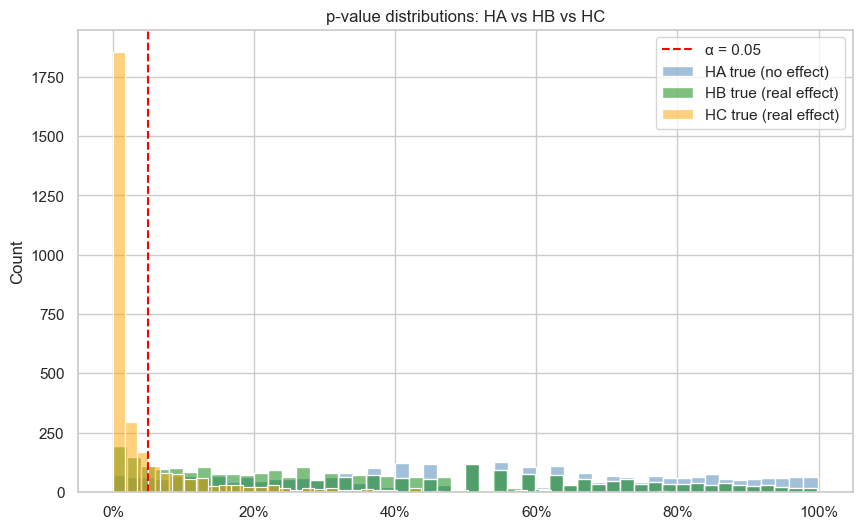

In [18]:
# (a) Plot p-value distributions for all 3 scenarios as overlapping histograms.
plt.figure(figsize=(10,6))
sns.histplot(p_values_ha, bins=50, alpha=0.5, label='HA true (no effect)', color='steelblue')
sns.histplot(p_values_hb, bins=50, alpha=0.5, label='HB true (real effect)', color='green')
sns.histplot(p_values_hc, bins=50, alpha=0.5, label='HC true (real effect)', color='orange')
plt.axvline(0.05, color='red', linestyle='--', label='α = 0.05')
plt.gca().xaxis.set_major_formatter('{:.0%}'.format)
plt.legend()
plt.title('p-value distributions: HA vs HB vs HC')
plt.show()

In [27]:
# (b) For each scenario: what % of tests are significant at alpha=0.05?
print(f'Percentage of Significant Tests at alpha = 0.05 for HA: {sum(p_values_ha<0.05)/len(p_values_ha)*100:.2f}%')
print(f'Percentage of Significant Tests at alpha = 0.05 for HB: {sum(p_values_hb<0.05)/len(p_values_hb)*100:.2f}%')
print(f'Percentage of Significant Tests at alpha = 0.05 for HC: {sum(p_values_hc<0.05)/len(p_values_hc)*100:.2f}%')

Percentage of Significant Tests at alpha = 0.05 for HA: 5.47%
Percentage of Significant Tests at alpha = 0.05 for HB: 13.07%
Percentage of Significant Tests at alpha = 0.05 for HC: 77.20%


````
(c) Add vertical lines at p=0.05. What does the area to the left represent in each case?
The vertical line at p=0.05 separates significant results from non-significant ones, where the area to its left represents the Type I Error rate (False Positive rate) for Scenario A since the null hypothesis is true. 
For Scenarios B and C where a real effect exists, the area to the left represents the Statistical Power (1−β), which is the probability of correctly rejecting the null hypothesis to detect that true effect.

In [74]:
# (d) What would happen if you ran 100 simultaneous tests all from Scenario A?

from scipy.stats import norm
np.random.seed(420)
n = 500
n_tests = 100
alpha = 0.05

control_sim = np.random.binomial(n, 0.1, size=n_tests)
test_sim    = np.random.binomial(n, 0.1, size=n_tests)
p_values = np.array([
    proportions_ztest([test_sim[i], control_sim[i]], [n, n], alternative='larger')[1]
    for i in range(n_tests)])

significant_indices = np.where(p_values < alpha)[0]
num_false_positives = len(significant_indices)

print(f"Total Tests Run: {n_tests}")
print(f"Number of 'Statistically Significant' False Positives: {num_false_positives}")
print(f"Indices of false positive tests: {significant_indices}")
print(f"p-values of those tests: {p_values[significant_indices]}")
# Apply Bonferroni correction
bonferroni_threshold = 0.05 / n_tests  # 0.0005
survivors = np.sum(p_values < bonferroni_threshold)
print(f"After Bonferroni correction: {survivors} tests remain significant")

Total Tests Run: 100
Number of 'Statistically Significant' False Positives: 6
Indices of false positive tests: [48 50 51 55 82 85]
p-values of those tests: [0.04000873 0.02245682 0.04439821 0.0370497  0.02212325 0.03593149]
After Bonferroni correction: 0 tests remain significant


---

### Q4 — Effect size matters

```
# Three companies report A/B test wins:
# Company A: p=0.001, absolute lift = 0.1pp (from 5.0% to 5.1%), n=2,000,000
# Company B: p=0.04,  absolute lift = 2.5pp (from 10% to 12.5%), n=500
# Company C: p=0.03,  absolute lift = 0.8pp (from 8% to 8.8%), n=5000
# (a) Compute Cohen's h for each. Classify effect size.
# (b) Plot a 3-panel bar chart showing: conversion rates, absolute lift, Cohen's h.
# (c) Which result is most practically meaningful? Which is least?
# (d) Write a comment explaining the difference between statistical and practical significance.
```


In [45]:
# (a) Compute Cohen's h for each. Classify effect size.

from statsmodels.stats.proportion import proportion_effectsize

p_treatment_a, p_control_a = [0.051, 0.05]
ha = proportion_effectsize(p_treatment_a, p_control_a)
print(f"Cohen's h for Company A: {ha:.4f}")
print(f"Effect size interpretation for Company A: {'large' if ha >= 0.8 else 'Medium' if ha >= 0.5 else 'Small' if ha >= 0.2 else 'Negligible'}")


p_treatment_b, p_control_b = [0.125, 0.1]
hb = proportion_effectsize(p_treatment_b, p_control_b)
print(f"Cohen's h for Company B: {hb:.4f}")
print(f"Effect size interpretation for Company B: {'large' if hb >= 0.8 else 'Medium' if hb >= 0.5 else 'Small' if hb >= 0.2 else 'Negligible'}")

p_treatment_c, p_control_c = [0.088, 0.08]
hc = proportion_effectsize(p_treatment_c, p_control_c)
print(f"Cohen's h for Company C: {hc:.4f}")
print(f"Effect size interpretation for Company C: {'large' if hc >= 0.8 else 'Medium' if hc >= 0.5 else 'Small' if hc >= 0.2 else 'Negligible'}")

Cohen's h for Company A: 0.0046
Effect size interpretation for Company A: Negligible
Cohen's h for Company B: 0.0792
Effect size interpretation for Company B: Negligible
Cohen's h for Company C: 0.0288
Effect size interpretation for Company C: Negligible


In [53]:
# (b) Plot a 3-panel bar chart showing: conversion rates, absolute lift, Cohen's h.

data = {
    'Company': ['Company A', 'Company B', 'Company C'],
    'Control': [5.0, 10.0, 8.0],       # in %
    'Treatment': [5.1, 12.5, 8.8],   # in %
    'Absolute Lift (pp)': [0.1, 2.5, 0.8],
    "Cohen's h": [ha, hb, hc]
}
df = pd.DataFrame(data)
display(df)

df_melted = df.melt(id_vars='Company', value_vars=['Control', 'Treatment'], 
                    var_name='Group', value_name='Conversion Rate (%)')
display(df_melted)

,Company,Control,Treatment,Absolute Lift (pp),Cohen's h
0,Company A,5.0,5.1,0.1,0.004567
1,Company B,10.0,12.5,2.5,0.079233
2,Company C,8.0,8.8,0.8,0.028848


,Company,Group,Conversion Rate (%)
0,Company A,Control,5.0
1,Company B,Control,10.0
2,Company C,Control,8.0
3,Company A,Treatment,5.1
4,Company B,Treatment,12.5
5,Company C,Treatment,8.8


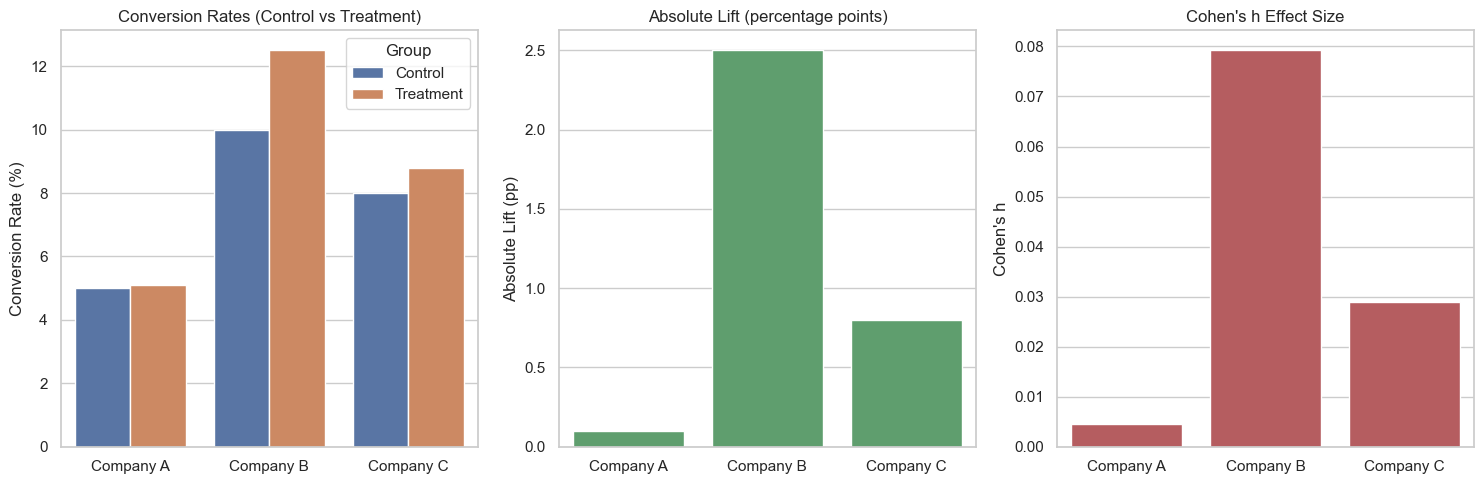

In [54]:
# Initialize a 1-row, 3-column matplotlib figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Grouped Bar Chart for Conversion Rates
sns.barplot(data=df_melted, x='Company', y='Conversion Rate (%)', hue='Group', 
            palette='deep', ax=axes[0])
axes[0].set_title('Conversion Rates (Control vs Treatment)')
axes[0].set_xlabel('')


# Panel 2: Absolute Lift (pp)
sns.barplot(data=df, x='Company', y='Absolute Lift (pp)', 
            color=sns.color_palette('deep')[2], ax=axes[1])
axes[1].set_title('Absolute Lift (percentage points)')
axes[1].set_xlabel('')

# Panel 3: Cohen's h Effect Size
sns.barplot(data=df, x='Company', y="Cohen's h", 
            color=sns.color_palette('deep')[3], ax=axes[2])
axes[2].set_title("Cohen's h Effect Size")
axes[2].set_xlabel('')

# Clean up spacing and save the plot
plt.tight_layout()
#plt.savefig('ab_test_sns_panels.png', dpi=300)

plt.show()

```
(c) Which result is most practically meaningful? Which is least?
Company A's result is the most practically meaningful because, despite its tiny absolute lift, its massive sample size (n=2,000,000) provides the high statistical certainty required to reliably drive substantial, scaled revenue or volume shifts in production. 
Conversely, Company B's result is the least practically meaningful; though a 2.5pp lift sounds impressive, a sample size of only 500 makes the test highly underpowered and volatile, indicating the "win" is likely an inflated false alarm driven by random noise. 
Company C sits in the middle, offering a balanced, reliable mid-sized win.

```
(d) Write a comment explaining the difference between statistical and practical significance.
STATISTICAL SIGNIFICANCE (Is it real?): Measures if a result is unlikely to occur by random chance. 
It scales with sample size (n); huge samples (Company A) yield tiny p-values even for microscopic, mathematically negligible deltas (Cohen's h near 0).

PRACTICAL SIGNIFICANCE (Does it matter?): Measures the real-world magnitude and business value of the effect.
Company B has high raw impact (+2.5pp) but low sample size (n=500), making it statistically unreliable (p=0.04),
while Company A has a tiny lift (+0.1pp) that is highly practical because scaling it over 2M users drives massive revenue.

---

### Q5 — End-to-end A/B test report function

```
# Write a function ab_test_report(n_ctrl, conv_ctrl, n_trt, conv_trt, monthly_visitors, revenue_per_conv)
# that returns and prints:
# - Conversion rates for both groups
# - Absolute lift, relative lift, 95% CI for the difference
# - z-statistic, p-value, Cohen's h
# - Expected monthly revenue impact (point estimate + CI)
# - A clear SHIP / DO NOT SHIP recommendation with justification
# - A 2-panel chart: (1) conversion bars with CI, (2) lift distribution
# Test it with the Q1 data AND with a scenario where the result is NOT significant.
# This function is portfolio-ready production code.
```


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from statsmodels.stats.proportion import proportion_effectsize

def ab_test_report(n_ctrl, conv_ctrl, n_trt, conv_trt, monthly_visitors, revenue_per_conv, alpha=0.05):
    """
    Evaluates an A/B test from raw conversion counts and generates a comprehensive,
    portfolio-grade business and statistical report alongside diagnostic charts.
    """
    # 1. Input Validation and Guardrails
    if min(n_ctrl, n_trt) <= 0 or min(conv_ctrl, conv_trt) < 0:
        raise ValueError("Sample sizes must be positive and conversions cannot be negative.")
    if conv_ctrl > n_ctrl or conv_trt > n_trt:
        raise ValueError("Conversions cannot exceed total sample size (n).")
        
    # 2. Conversion and Lift Calculations
    cr_ctrl = conv_ctrl / n_ctrl
    cr_trt = conv_trt / n_trt
    
    abs_lift = cr_trt - cr_ctrl
    rel_lift = (cr_trt - cr_ctrl) / cr_ctrl if cr_ctrl > 0 else 0.0
    
    # 3. Frequentist Hypothesis Testing & Confidence Interval (Wald Interval)
    p_pooled = (conv_ctrl + conv_trt) / (n_ctrl + n_trt)
    se_pooled = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_ctrl + 1/n_trt))
    se_unpooled = np.sqrt((cr_ctrl * (1 - cr_ctrl) / n_ctrl) + (cr_trt * (1 - cr_trt) / n_trt))
    
    z_stat = abs_lift / se_pooled if se_pooled > 0 else 0.0
    p_value = 2 * (1 - norm.cdf(np.abs(z_stat)))
    
    z_critical = norm.ppf(1 - alpha / 2)
    ci_lower = abs_lift - (z_critical * se_unpooled)
    ci_upper = abs_lift + (z_critical * se_unpooled)
    
    # 4. Effect Size Metrics
    cohens_h = proportion_effectsize(cr_trt, cr_ctrl)
    
    # 5. Financial Modeling & Projections
    expected_monthly_lift_conversions = (monthly_visitors / 2) * abs_lift
    expected_rev_impact = expected_monthly_lift_conversions * revenue_per_conv
    
    rev_ci_lower = ((monthly_visitors / 2) * ci_lower) * revenue_per_conv
    rev_ci_upper = ((monthly_visitors / 2) * ci_upper) * revenue_per_conv
    
    # 6. Recommendation Framework
    is_stat_sig = p_value < alpha
    is_positive_direction = abs_lift > 0
    
    if is_stat_sig and is_positive_direction:
        recommendation = "SHIP"
        justification = (
            f"The variant statistically outperformed control (p={p_value:.4f}) with a solid absolute "
            f"lift of +{abs_lift*100:.2f}pp. Minimum projected monthly financial lift is "
            f"${max(0, rev_ci_lower):,.2f} at a 95% confidence level."
        )
    elif is_stat_sig and not is_positive_direction:
        recommendation = "DO NOT SHIP (Negative Impact)"
        justification = (
            f"The variant caused a statistically significant regression in conversion (p={p_value:.4f}). "
            f"Deploying this change risks an estimated monthly revenue loss of up to ${abs(rev_ci_lower):,.2f}."
        )
    else:
        recommendation = "DO NOT SHIP (Inconclusive)"
        justification = (
            f"The results are not statistically significant (p={p_value:.4f} > alpha={alpha}). "
            f"The observed metric difference is statistically indistinguishable from random noise. "
            f"Maintain control baseline or iterate on the feature."
        )
        
    # 7. Print Executable Text Report
    print("="*65)
    print(f" EXPERIMENT REPORT SUMMARY | STATUS: {recommendation}")
    print("="*65)
    print(f"• Baseline Metrics:")
    print(f"  - Control CR:   {cr_ctrl*100:.3f}% (n={n_ctrl:,})")
    print(f"  - Treatment CR: {cr_trt*100:.3f}% (n={n_trt:,})")
    print(f"• Core Deltas:")
    print(f"  - Absolute Lift: {abs_lift*100:+.3f} percentage points")
    print(f"  - Relative Lift: {rel_lift*100:+.2f}%")
    print(f"  - 95% Diff CI:   [{ci_lower*100:.3f}%, {ci_upper*100:.3f}%]")
    print(f"• Inference Engine:")
    print(f"  - Z-Statistic:   {z_stat:.4f} | p-value: {p_value:.4e}")
    print(f"  - Cohen's h:     {cohens_h:.4f}")
    print(f"• Scaled Projections (Monthly):")
    print(f"  - Expected Financial Impact: ${expected_rev_impact:+,.2f}/mo")
    print(f"  - 95% Revenue Impact CI:    [${rev_ci_lower:,.2f}, ${rev_ci_upper:,.2f}]")
    print(f"• Justification:\n  {justification}\n")
    
    # 8. Data Visualization Layer
    sns.set_theme(style="whitegrid", palette="muted")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    
    # Panel 1: Conversion Bars with 95% Wald Confidence Intervals
    error_ctrl = z_critical * np.sqrt(cr_ctrl * (1 - cr_ctrl) / n_ctrl)
    error_trt = z_critical * np.sqrt(cr_trt * (1 - cr_trt) / n_trt)
    
    sns.barplot(x=['Control', 'Treatment'], y=[cr_ctrl*100, cr_trt*100], 
                palette=['#4C72B0', '#55A868'], ax=axes[0], edgecolor='k', lw=1)
    axes[0].errorbar(x=[0, 1], y=[cr_ctrl*100, cr_trt*100], 
                     yerr=[error_ctrl*100, error_trt*100], fmt='none', c='black', capsize=6, lw=1.5)
    axes[0].set_ylabel('Conversion Rate (%)', fontweight='bold')
    axes[0].set_title('Conversion Rates with 95% Confidence Intervals', fontweight='bold', pad=10)
    
    # Panel 2: Lift Distribution (Sampling Error Normal Distribution Curve)
    lift_axis = np.linspace(abs_lift - 4*se_unpooled, abs_lift + 4*se_unpooled, 500)
    lift_pdf = norm.pdf(lift_axis, abs_lift, se_unpooled)
    
    axes[1].plot(lift_axis * 100, lift_pdf, color='#DD8452', lw=2, label='Lift Probability Density')
    axes[1].fill_between(lift_axis * 100, 0, lift_pdf, color='#DD8452', alpha=0.3)
    axes[1].axvline(0, color='black', linestyle='--', alpha=0.7, label='Zero Equality Point')
    axes[1].axvline(abs_lift * 100, color='red', linestyle=':', label=f'Observed Lift ({abs_lift*100:+.2f}pp)')
    axes[1].set_xlabel('Absolute Lift Distribution (pp)', fontweight='bold')
    axes[1].set_ylabel('Density', fontweight='bold')
    axes[1].set_title('Sampling Distribution of the Delta (Absolute Lift)', fontweight='bold', pad=10)
    axes[1].legend(loc='upper right')
    
    plt.tight_layout()
    
    # Return metrics packaged as a clean python dictionary
    metrics = {
        'conversion_rates': (cr_ctrl, cr_trt), 'absolute_lift': abs_lift, 'relative_lift': rel_lift,
        'ci_diff': (ci_lower, ci_upper), 'z_stat': z_stat, 'p_value': p_value, 'cohens_h': cohens_h,
        'expected_monthly_revenue': expected_rev_impact, 'revenue_ci': (rev_ci_lower, rev_ci_upper),
        'recommendation': recommendation, 'fig': fig
    }
    return metrics


 EXPERIMENT REPORT SUMMARY | STATUS: SHIP
• Baseline Metrics:
  - Control CR:   5.000% (n=2,000,000)
  - Treatment CR: 5.100% (n=2,000,000)
• Core Deltas:
  - Absolute Lift: +0.100 percentage points
  - Relative Lift: +2.00%
  - 95% Diff CI:   [0.057%, 0.143%]
• Inference Engine:
  - Z-Statistic:   4.5667 | p-value: 4.9535e-06
  - Cohen's h:     0.0046
• Scaled Projections (Monthly):
  - Expected Financial Impact: $+37,500.00/mo
  - 95% Revenue Impact CI:    [$21,405.73, $53,594.27]
• Justification:
  The variant statistically outperformed control (p=0.0000) with a solid absolute lift of +0.10pp. Minimum projected monthly financial lift is $21,405.73 at a 95% confidence level.



{'conversion_rates': (0.05, 0.051),
 'absolute_lift': 0.000999999999999994,
 'relative_lift': 0.01999999999999988,
 'ci_diff': (np.float64(0.0005708193507124556),
  np.float64(0.0014291806492875323)),
 'z_stat': np.float64(4.566745677758798),
 'p_value': np.float64(4.95354396901071e-06),
 'cohens_h': np.float64(0.004566799813746858),
 'expected_monthly_revenue': 37499.999999999774,
 'revenue_ci': (np.float64(21405.725651717086), np.float64(53594.27434828246)),
 'recommendation': 'SHIP',
 'fig': <Figure size 1400x550 with 2 Axes>}

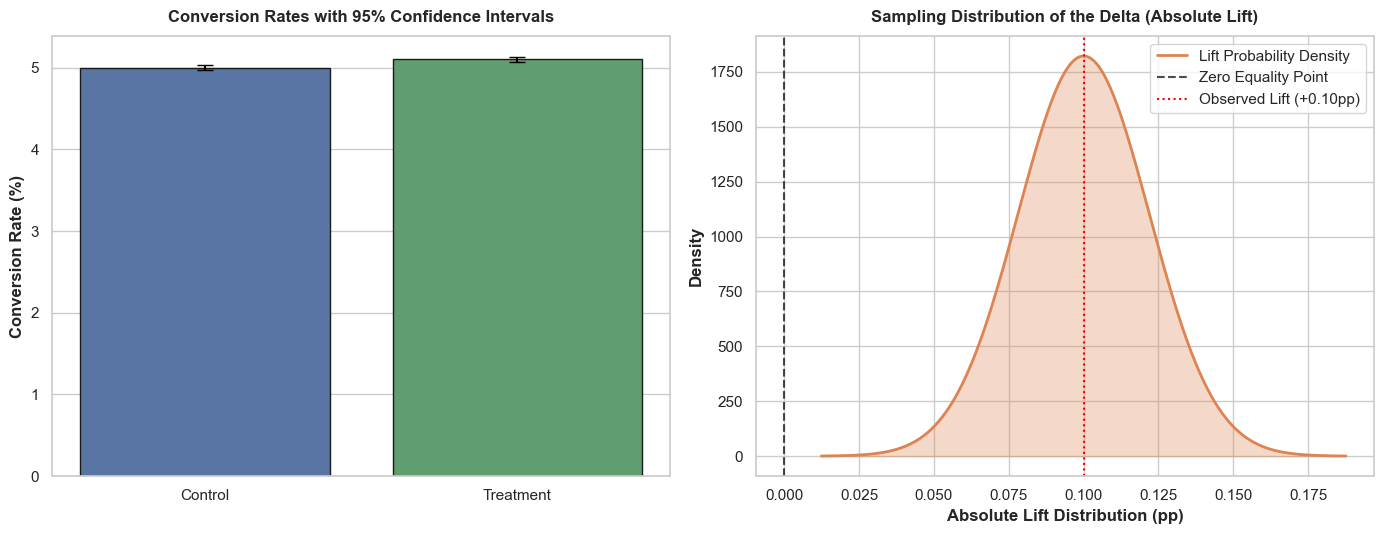

In [57]:
# test the function using Company A: p=0.001, absolute lift = 0.1pp (from 5.0% to 5.1%), n=2,000,000
n_control_a = 2_000_000
conv_control_a = int(n_control_a * 0.050)  # 5% of 2M = 100,000 conversions

n_treatment_a = 2_000_000
conv_treatment_a = int(n_treatment_a * 0.051)  # 5.1% of 2M = 102,000 conversions

# Let's assume a highly-trafficked platform with $15 per conversion value
MONTHLY_VISITORS_A = 5_000_000
REVENUE_PER_CONV_A = 15.00

# ab_test_report(n_ctrl, conv_ctrl, n_trt, conv_trt, monthly_visitors, revenue_per_conv, alpha=0.05):

ab_test_report(
    n_ctrl=n_control_a, 
    conv_ctrl=conv_control_a, 
    n_trt=n_treatment_a, 
    conv_trt=conv_treatment_a, 
    monthly_visitors=MONTHLY_VISITORS_A, 
    revenue_per_conv=REVENUE_PER_CONV_A
)

 EXPERIMENT REPORT SUMMARY | STATUS: DO NOT SHIP (Inconclusive)
• Baseline Metrics:
  - Control CR:   10.000% (n=500)
  - Treatment CR: 12.400% (n=500)
• Core Deltas:
  - Absolute Lift: +2.400 percentage points
  - Relative Lift: +24.00%
  - 95% Diff CI:   [-1.506%, 6.306%]
• Inference Engine:
  - Z-Statistic:   1.2033 | p-value: 2.2887e-01
  - Cohen's h:     0.0762
• Scaled Projections (Monthly):
  - Expected Financial Impact: $+900,000.00/mo
  - 95% Revenue Impact CI:    [$-564,907.55, $2,364,907.55]
• Justification:
  The results are not statistically significant (p=0.2289 > alpha=0.05). The observed metric difference is statistically indistinguishable from random noise. Maintain control baseline or iterate on the feature.



{'conversion_rates': (0.1, 0.124),
 'absolute_lift': 0.023999999999999994,
 'relative_lift': 0.23999999999999994,
 'ci_diff': (np.float64(-0.015064201433065291),
  np.float64(0.06306420143306528)),
 'z_stat': np.float64(1.2032773777797232),
 'p_value': np.float64(0.22886900026455015),
 'cohens_h': np.float64(0.07620421723133186),
 'expected_monthly_revenue': 899999.9999999998,
 'revenue_ci': (np.float64(-564907.5537399484),
  np.float64(2364907.5537399477)),
 'recommendation': 'DO NOT SHIP (Inconclusive)',
 'fig': <Figure size 1400x550 with 2 Axes>}

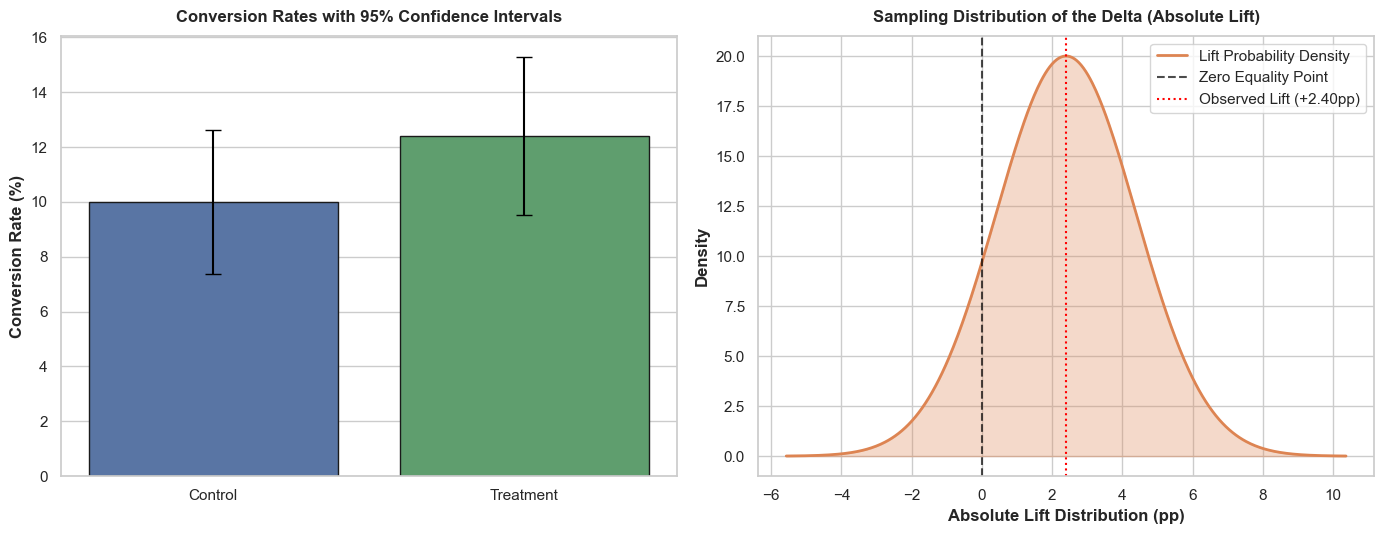

In [ ]:
# test the function using Company B: p=0.04,  absolute lift = 2.5pp (from 10% to 12.5%), n=500
n_control_b = 500
conv_control_b = int(n_control_b * 0.1)  # 10% of 500 = 50 conversions

n_treatment_b = 500
conv_treatment_b = int(n_treatment_b * 0.125)  # 12.5% of 500 = 63 conversions

# Let's assume a highly-trafficked platform with $15 per conversion value
MONTHLY_VISITORS_B = 5_000_000
REVENUE_PER_CONV_B = 15.00

# ab_test_report(n_ctrl, conv_ctrl, n_trt, conv_trt, monthly_visitors, revenue_per_conv, alpha=0.05):

ab_test_report(
    n_ctrl=n_control_b, 
    conv_ctrl=conv_control_b, 
    n_trt=n_treatment_b, 
    conv_trt=conv_treatment_b, 
    monthly_visitors=MONTHLY_VISITORS_B, 
    revenue_per_conv=REVENUE_PER_CONV_B
)

 EXPERIMENT REPORT SUMMARY | STATUS: DO NOT SHIP (Inconclusive)
• Baseline Metrics:
  - Control CR:   8.000% (n=5,000)
  - Treatment CR: 8.800% (n=5,000)
• Core Deltas:
  - Absolute Lift: +0.800 percentage points
  - Relative Lift: +10.00%
  - 95% Diff CI:   [-0.287%, 1.887%]
• Inference Engine:
  - Z-Statistic:   1.4420 | p-value: 1.4930e-01
  - Cohen's h:     0.0288
• Scaled Projections (Monthly):
  - Expected Financial Impact: $+300,000.00/mo
  - 95% Revenue Impact CI:    [$-107,710.20, $707,710.20]
• Justification:
  The results are not statistically significant (p=0.1493 > alpha=0.05). The observed metric difference is statistically indistinguishable from random noise. Maintain control baseline or iterate on the feature.



{'conversion_rates': (0.08, 0.088),
 'absolute_lift': 0.007999999999999993,
 'relative_lift': 0.09999999999999991,
 'ci_diff': (np.float64(-0.002872271964191441),
  np.float64(0.018872271964191428)),
 'z_stat': np.float64(1.4420244082001075),
 'p_value': np.float64(0.1492954880400028),
 'cohens_h': np.float64(0.02884823961208627),
 'expected_monthly_revenue': 299999.9999999997,
 'revenue_ci': (np.float64(-107710.19865717905),
  np.float64(707710.1986571786)),
 'recommendation': 'DO NOT SHIP (Inconclusive)',
 'fig': <Figure size 1400x550 with 2 Axes>}

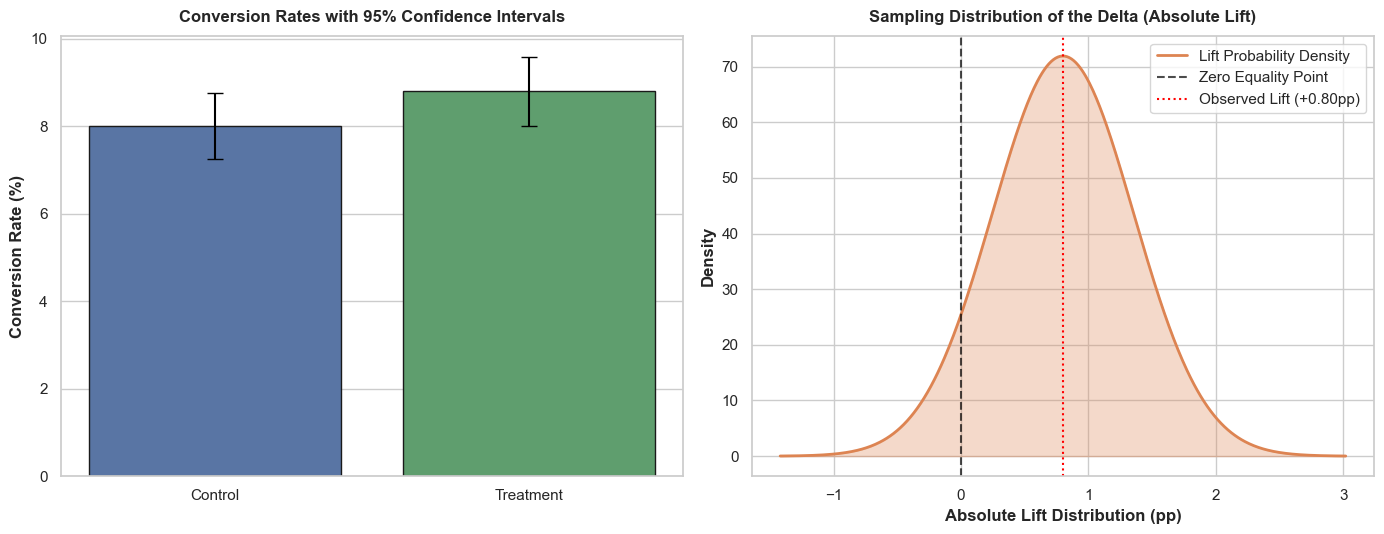

In [66]:
# test the function using Company C: p=0.03,  absolute lift = 0.8pp (from 8% to 8.8%), n=5000
n_control_c = 5000
conv_control_c = int(n_control_c * 0.08)  # 8% of 5k = 400 conversions

n_treatment_c = 5000
conv_treatment_c = int(n_treatment_c * 0.088)  # 8.8% of 5k = 440 conversions

# Let's assume a highly-trafficked platform with $15 per conversion value
MONTHLY_VISITORS_C = 5_000_000
REVENUE_PER_CONV_C = 15.00

# ab_test_report(n_ctrl, conv_ctrl, n_trt, conv_trt, monthly_visitors, revenue_per_conv, alpha=0.05):

ab_test_report(
    n_ctrl=n_control_c, 
    conv_ctrl=conv_control_c, 
    n_trt=n_treatment_c, 
    conv_trt=conv_treatment_c, 
    monthly_visitors=MONTHLY_VISITORS_C, 
    revenue_per_conv=REVENUE_PER_CONV_C
)